In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path

def load_all_results(dir, tree_names=["heggarty2024", "long_v3_CCD0.0.25"]):
    """Load all phylolm/lm and OAK results."""
    
    # Initialize storage
    phylolm_bayesian_results = []
    oak_results = []
    oak_shap_results = []
    
    
    # Load phylolm_bayesian results
    csv_files = []
    for tree_name in tree_names:
        csv_files += glob.glob(f"results_clean2_bayesian/phylolm_*{tree_name}*.csv")

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        # Extract configuration from filename
        filename = Path(csv_file).stem
        parts = filename.split("_")
        
        # Add to list
        phylolm_bayesian_results.append(df)

    # Rename interaction to interactionbool AFTER all files are loaded
    for phylolm_bayesian_df in phylolm_bayesian_results:
        if 'interaction' in phylolm_bayesian_df.columns:
            phylolm_bayesian_df.rename(columns={'interaction': 'interactionbool'}, inplace=True)

    # Load OAK Sobol indices
    sobol_csv_files = []
    for tree_name in tree_names:
        sobol_csv_files += glob.glob(f"results_clean2/oak_sobol_*{tree_name}*.csv")
        # sobol_csv_files += glob.glob(f"results_clean2/oak_sobol_*{tree_name}*.csv")

    for csv_file in sobol_csv_files:
        df = pd.read_csv(csv_file)
        # Extract configuration from filename
        filename = Path(csv_file).stem
        
        # Parse configuration
        config = {}
        
        # First, find and set the tree name
        for tree_name in tree_names:
            if tree_name in filename:
                config['tree'] = tree_name
                break
        
        # Then parse the boolean parameters
        parts = filename.split("_")
        for i, part in enumerate(parts):
            # Look for exact patterns to avoid confusion
            if part == "mercatorTrue":
                config['mercator'] = True
            elif part == "mercatorFalse":
                config['mercator'] = False
            elif part == "interactionTrue":
                config['interactionbool'] = True
            elif part == "interactionFalse":
                config['interactionbool'] = False
            elif part == "blocklatlonTrue":
                config['block_latlon'] = True
            elif part == "blocklatlonFalse":
                config['block_latlon'] = False
            elif part == "phylocovTrue":
                config['add_phylocov'] = True
            elif part == "phylocovFalse":
                config['add_phylocov'] = False
            elif part == "empiricalspatialTrue":
                config['empiricalspatial'] = True
            elif part == "empiricalspatialFalse":
                config['empiricalspatial'] = False

        # Add config to dataframe
        for key, val in config.items():
            df[key] = val
            
        oak_results.append(df)

    # Load OAK SHAP indices
    shap_csv_files = []
    for tree_name in tree_names:
        shap_csv_files += glob.glob(f"results_clean2/oak_SHAPLEY_*{tree_name}*empiricalspatialTrue.csv")
        # shap_csv_files += glob.glob(f"results_clean2/oak_shap_*{tree_name}*.csv")

    for csv_file in shap_csv_files:
        df = pd.read_csv(csv_file)
        # Extract configuration from filename
        filename = Path(csv_file).stem
        
        # Parse configuration
        config = {}
        
        # First, find and set the tree name
        for tree_name in tree_names:
            if tree_name in filename:
                config['tree'] = tree_name
                break
        
        # Then parse the boolean parameters
        parts = filename.split("_")
        for i, part in enumerate(parts):
            # Look for exact patterns to avoid confusion
            if part == "mercatorTrue":
                config['mercator'] = True
            elif part == "mercatorFalse":
                config['mercator'] = False
            elif part == "interactionTrue":
                config['interactionbool'] = True
            elif part == "interactionFalse":
                config['interactionbool'] = False
            elif part == "blocklatlonTrue":
                config['block_latlon'] = True
            elif part == "blocklatlonFalse":
                config['block_latlon'] = False
            elif part == "phylocovTrue":
                config['add_phylocov'] = True
            elif part == "phylocovFalse":
                config['add_phylocov'] = False
            elif part == "empiricalspatialTrue":
                config['empiricalspatial'] = True
            elif part == "empiricalspatialFalse":
                config['empiricalspatial'] = False

        # Add config to dataframe
        for key, val in config.items():
            df[key] = val

        oak_shap_results.append(df)

    # Combine dataframes
    phylolm_bayesian_df = pd.concat(phylolm_bayesian_results, ignore_index=True) if phylolm_bayesian_results else pd.DataFrame()
    oak_df = pd.concat(oak_results, ignore_index=True) if oak_results else pd.DataFrame()
    oak_shap_df = pd.concat(oak_shap_results, ignore_index=True) if oak_shap_results else pd.DataFrame()

    return phylolm_bayesian_df, oak_df, oak_shap_df

# Load the data
dir = "results_clean2"
phylolm_bayesian_df, oak_df, oak_shap_df = load_all_results(dir=dir)

In [12]:
# filter out add_phylocov == False
# oak_df = oak_df[oak_df['add_phylocov'] == True]
phylolm_bayesian_df = phylolm_bayesian_df[
    (phylolm_bayesian_df['add_phylocov'] == True)&
    (phylolm_bayesian_df['interactionbool'] == True)&
    (phylolm_bayesian_df['block_latlon'] == False)&
    (phylolm_bayesian_df['mercator'] == False)
]
oak_df = oak_df[
    (oak_df['add_phylocov'] == True)&
    (oak_df['interactionbool'] == True)&
    (oak_df['block_latlon'] == False)&
    (oak_df['mercator'] == False)
]

In [13]:
# rename tree names for plotting
tree_name_map = {
    "heggarty2024": "Cognates",
    "long_v3_CCD0.0.25": "Speech (25%)"
}
phylolm_bayesian_df['tree'] = phylolm_bayesian_df['tree'].map(tree_name_map)
oak_df['tree'] = oak_df['tree'].map(tree_name_map)

In [14]:
oak_df

,interaction,sobol_index,tree,mercator,interactionbool,block_latlon,add_phylocov,empiricalspatial
36,normalized_phylo_variance,0.437491,Cognates,False,True,False,True,True
37,lon,0.277715,Cognates,False,True,False,True,True
38,lat,0.146099,Cognates,False,True,False,True,True
39,lat & log_speakers,0.090549,Cognates,False,True,False,True,True
40,lon & log_speakers,0.025819,Cognates,False,True,False,True,True
41,lon & lat,0.017091,Cognates,False,True,False,True,True
42,log_speakers,0.005236,Cognates,False,True,False,True,True
43,normalized_likelihood_variance,0.000002,Cognates,False,True,False,True,True
125,normalized_phylo_variance,0.420185,Cognates,False,True,False,True,False
126,lon,0.331357,Cognates,False,True,False,True,False


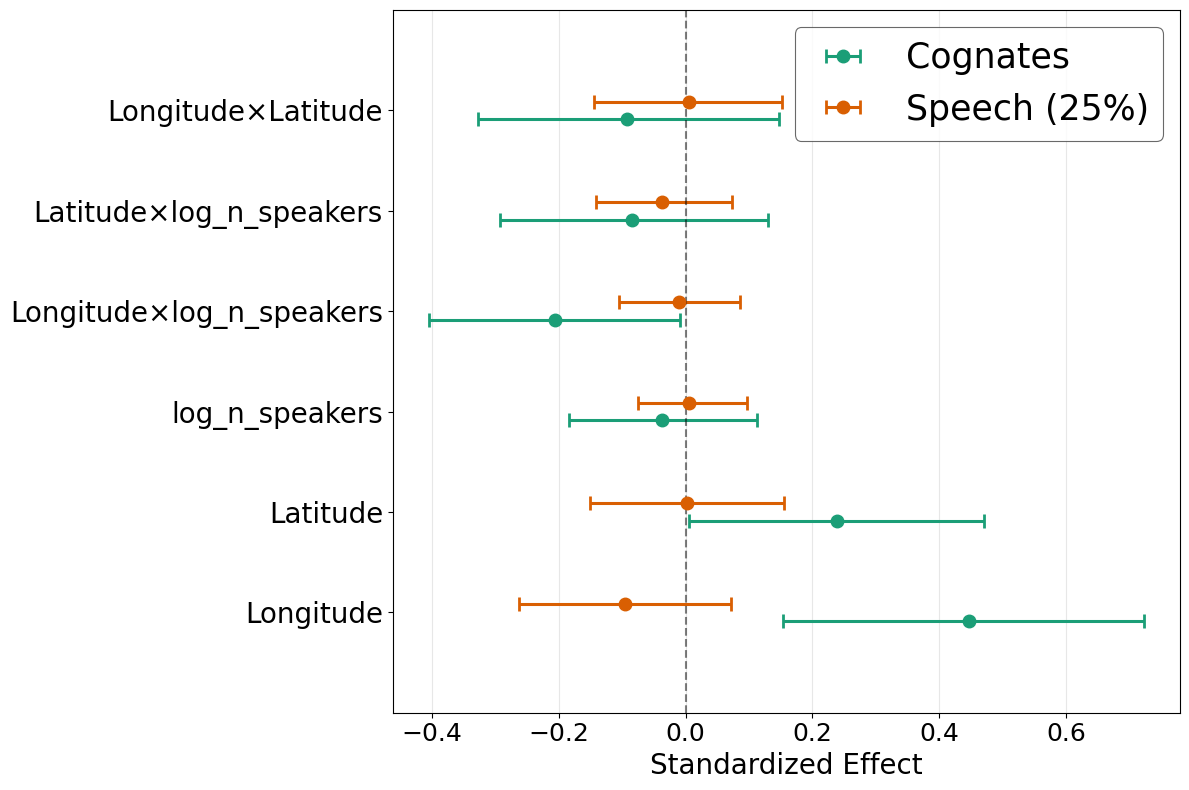

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# # ----------------------------
# # Helpers
# # ----------------------------
def _ensure_dir(path: str):
    d = os.path.dirname(path)
    if d and not os.path.exists(d):
        os.makedirs(d, exist_ok=True)

def _config_label(row):
    return f"{'Mercator' if row['mercator'] else 'LatLon'}-" \
           f"{'WithInteraction'  if row['interactionbool'] else 'NoInteraction'}-" \
           f"{'PhyloCov'  if row['add_phylocov'] else 'NoPhyloCov'}"

def _config_sort_key(cfg: str):
    # cfg looks like "LL-Main-Reg"
    p, o, h = cfg.split("-")
    proj  = {"LL":0, "Merc":1}.get(p, 2)
    order = {"Main":0, "Int":1}.get(o,  2)
    hyper = {"Reg":0,  "Phy":1}.get(h,  2)
    return (proj, order, hyper)

# unified color mapping with log_n_speakers naming
_COEF_COLORS = {
    'Longitude': '#1f77b4',
    'Latitude':  '#ff7f0e',
    'log_n_speakers': '#2ca02c',
    'Longitude×log_n_speakers': '#9467bd',
    'Latitude×log_n_speakers':  '#e377c2',
    'Longitude×Latitude':    '#d62728'
}

def _effect_bayesian_column_map(is_merc: bool, has_interactions: bool):
    """
    Return { display_name : (coef_col, ci_lower, ci_upper, is_interaction) }
    Picks Mercator vs LL columns; adds interactions only if has_interactions=True.
    Display names use 'log_n_speakers' (not log(N)).
    """
    effects = {
        'Longitude': ('coef_x' if is_merc else 'coef_longitude',
                      'ci_lower_x'   if is_merc else 'ci_lower_longitude',
                      'ci_upper_x'   if is_merc else 'ci_upper_longitude',
                      False),
        'Latitude':  ('coef_y' if is_merc else 'coef_latitude',
                      'ci_lower_y'   if is_merc else 'ci_lower_latitude',
                        'ci_upper_y'   if is_merc else 'ci_upper_latitude',
                        False),
        'log_n_speakers': ('coef_log_n_speakers', 'ci_lower_log_n_speakers', 'ci_upper_log_n_speakers', False),
    }
    if has_interactions:
        effects.update({
            'Longitude×log_n_speakers': ('coef_x_log_n_speakers' if is_merc else 'coef_longitude_log_n_speakers',
                                    'ci_lower_x_log_n_speakers'   if is_merc else 'ci_lower_longitude_log_n_speakers',
                                    'ci_upper_x_log_n_speakers'   if is_merc else 'ci_upper_longitude_log_n_speakers',
                                    True),
            'Latitude×log_n_speakers':  ('coef_y_log_n_speakers' if is_merc else 'coef_latitude_log_n_speakers',
                                    'ci_lower_y_log_n_speakers'   if is_merc else 'ci_lower_latitude_log_n_speakers',
                                    'ci_upper_y_log_n_speakers'   if is_merc else 'ci_upper_latitude_log_n_speakers',
                                    True),
            'Longitude×Latitude':            ('coef_x_y' if is_merc else 'coef_longitude_latitude',
                                    'ci_lower_x_y'   if is_merc else 'ci_lower_longitude_latitude',
                                    'ci_upper_x_y'   if is_merc else 'ci_upper_longitude_latitude',
                                    True),
        })
    return effects


# ----------------------------
# Comparison plot (main + interactions)
# ----------------------------
def plot_bayesian_normalized_effects_comparison(dir, phylolm_df: pd.DataFrame, tree_colors=None):
    """Plot standardized effects with 95% credible intervals by coefficient and tree."""

    rows = []
    for _, row in phylolm_df.iterrows():
        cfg = _config_label(row)
        is_merc = bool(row['mercator'])
        has_int = bool(row.get('interactionbool', False))
        eff_map = _effect_bayesian_column_map(is_merc, has_int)

        for disp, (coef_col, ci_lower_col, ci_upper_col, _) in eff_map.items():
            if {coef_col, ci_lower_col, ci_upper_col}.issubset(phylolm_df.columns):
                est = row.get(coef_col)
                lower = row.get(ci_lower_col)
                upper = row.get(ci_upper_col)
                if pd.notna(est) and pd.notna(lower) and pd.notna(upper):
                    rows.append({
                        'coefficient': disp,
                        'tree': str(row['tree']),
                        'config': cfg,
                        'estimate': float(est),
                        'lower_ci': float(lower),
                        'upper_ci': float(upper)
                    })

    if not rows:
        print("No data found for comparison plot")
        return

    df = pd.DataFrame(rows)
    df = df.drop_duplicates(subset=['tree', 'coefficient', 'config'])
    coeff_order = ['Longitude', 'Latitude', 'log_n_speakers',
                   'Longitude×log_n_speakers', 'Latitude×log_n_speakers', 'Longitude×Latitude']
    df = df[df['coefficient'].isin(coeff_order)]
    df['coefficient'] = pd.Categorical(df['coefficient'], categories=coeff_order, ordered=True)
    df = df.sort_values(['coefficient', 'tree'])

    if df.empty:
        print("No coefficients matched the expected set")
        return

    trees = list(dict.fromkeys(df['tree']))
    if tree_colors is None:
        cmap = plt.get_cmap('Dark2')
        tree_colors = {t: cmap(i % cmap.N) for i, t in enumerate(trees)}

    fig, ax = plt.subplots(figsize=(12, 8))
    row_spacing = 4.0
    y_base = np.arange(len(coeff_order)) * row_spacing
    if len(trees) > 1:
        offsets = np.linspace(-0.35, 0.35, len(trees))
    else:
        offsets = [0.0]

    for offset, tree in zip(offsets, trees):
        sub = df[df['tree'] == tree].set_index('coefficient').reindex(coeff_order)
        est = sub['estimate'].to_numpy(dtype=float)
        lower = sub['lower_ci'].to_numpy(dtype=float)
        upper = sub['upper_ci'].to_numpy(dtype=float)
        mask = ~np.isnan(est)

        if not mask.any():
            continue

        y_positions = y_base + offset
        ax.errorbar(
            est[mask],
            y_positions[mask],
            xerr=[est[mask] - lower[mask], upper[mask] - est[mask]],
            fmt='o',
            color=tree_colors.get(tree, 'gray'),
            capsize=5,
            capthick=2,
            markersize=9,
            linewidth=2.2,
            label=tree
        )

    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_yticks(y_base)
    ax.set_yticklabels(coeff_order, fontsize=20)
    ax.set_ylim(-row_spacing, y_base[-1] + row_spacing)
    ax.set_xlabel('Standardized Effect', fontsize=20)
    ax.tick_params(axis='x', labelsize=18)
    ax.grid(True, axis='x', alpha=0.3)
    legend = ax.legend(title='', loc='best', fontsize=25, title_fontsize=25)
    if legend is not None:
        legend.get_frame().set_linewidth(0.8)
        legend.get_frame().set_edgecolor('#444444')

    plt.tight_layout()
    out = "final_figures/effects_comparison_bayesian_normalized_with_interactions.pdf"
    _ensure_dir(out)
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()


# ----------------------------
# Run the analyses
# ----------------------------
all_trees = phylolm_bayesian_df['tree'].unique()
cmap = plt.get_cmap("Dark2")
tree_colors = {t: cmap(i % cmap.N) for i, t in enumerate(all_trees)}
plot_bayesian_normalized_effects_comparison(dir=dir, phylolm_df=phylolm_bayesian_df, tree_colors=tree_colors)


## OAK Sobol

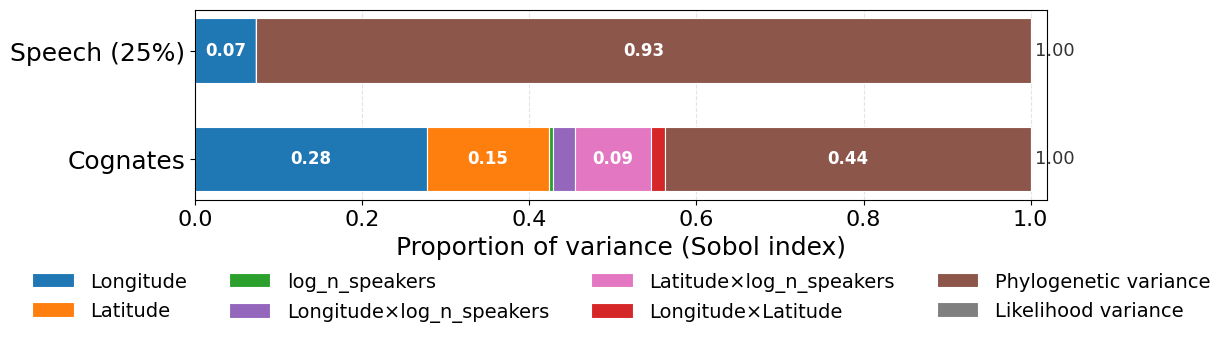

Saved stacked Sobol plot to final_figures/oak_stacked_by_tree.pdf


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SOBOL_COMPONENT_ORDER = [
    "Longitude",
    "Latitude",
    "log_n_speakers",
    "Longitude×log_n_speakers",
    "Latitude×log_n_speakers",
    "Longitude×Latitude",
    "Phylogenetic variance",
    "Likelihood variance",
]
SOBOL_COLORS = {
    "Longitude": "#1f77b4",
    "Latitude": "#ff7f0e",
    "log_n_speakers": "#2ca02c",
    "Longitude×log_n_speakers": "#9467bd",
    "Latitude×log_n_speakers": "#e377c2",
    "Longitude×Latitude": "#d62728",
    "Phylogenetic variance": "#8c564b",
    "Likelihood variance": "#7f7f7f",
}

_SOBOL_COMPONENT_ALIASES = {
    "lon": "Longitude",
    "longitude": "Longitude",
    "x": "Longitude",
    "lat": "Latitude",
    "latitude": "Latitude",
    "y": "Latitude",
    "log_speakers": "log_n_speakers",
    "logspeakers": "log_n_speakers",
    "log_n_speakers": "log_n_speakers",
    "logn_speakers": "log_n_speakers",
    "lon&log_speakers": "Longitude×log_n_speakers",
    "lon&logspeakers": "Longitude×log_n_speakers",
    "lon&log_n_speakers": "Longitude×log_n_speakers",
    "x&log_speakers": "Longitude×log_n_speakers",
    "x&logspeakers": "Longitude×log_n_speakers",
    "lat&log_speakers": "Latitude×log_n_speakers",
    "lat&logspeakers": "Latitude×log_n_speakers",
    "y&log_speakers": "Latitude×log_n_speakers",
    "y&logspeakers": "Latitude×log_n_speakers",
    "lon&lat": "Longitude×Latitude",
    "lonlat": "Longitude×Latitude",
    "x&y": "Longitude×Latitude",
    "normalized_phylo_variance": "Phylogenetic variance",
    "normalized_phylovariance": "Phylogenetic variance",
    "normalized_phylocovariance": "Phylogenetic variance",
    "normalized_likelihood_variance": "Likelihood variance",
}

def _map_sobol_component(raw_name):
    """Collapse raw interaction labels to display-friendly component names."""
    if pd.isna(raw_name):
        return None
    key = str(raw_name).strip().lower().replace(" ", "")
    key = key.replace("logn", "log_n")
    return _SOBOL_COMPONENT_ALIASES.get(key)

def plot_oak_sobol_stacked_by_tree(
    oak_df: pd.DataFrame,
    tree_order=None,
    empirical_only: bool = True,
    output_dir: str = "final_figures",
    file_stub: str = "oak_stacked_by_tree",
) -> None:
    """Plot Sobol variance fractions as stacked horizontal bars per tree."""
    if oak_df is None or oak_df.empty:
        print("oak_df is empty; nothing to plot.")
        return
    df = oak_df.copy()
    if empirical_only and "empiricalspatial" in df.columns:
        df = df[df["empiricalspatial"] == True]
    if df.empty:
        print("No Sobol rows after filtering; nothing to plot.")
        return
    df["component"] = df["interaction"].map(_map_sobol_component)
    df = df.dropna(subset=["component", "sobol_index"])
    if df.empty:
        print("No recognised Sobol components to plot.")
        return
    value_col = "sobol_index" if "sobol_index" in df.columns else df.columns[-1]
    summary = df.groupby(["tree", "component"])[value_col].mean().unstack(fill_value=0.0)
    for comp in SOBOL_COMPONENT_ORDER:
        if comp not in summary.columns:
            summary[comp] = 0.0
    summary = summary[SOBOL_COMPONENT_ORDER]
    if tree_order is None:
        tree_order = list(dict.fromkeys(df["tree"]))
    summary = summary.reindex(tree_order).fillna(0.0)
    fig_height = max(3.8, 1.35 * len(summary.index))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    y_positions = np.arange(len(summary.index))
    left = np.zeros(len(summary.index))
    for comp in SOBOL_COMPONENT_ORDER:
        values = summary[comp].to_numpy(dtype=float)
        if np.allclose(values, 0.0):
            continue
        bars = ax.barh(
            y_positions,
            values,
            left=left,
            height=0.6,
            color=SOBOL_COLORS.get(comp, "#999999"),
            edgecolor="white",
            linewidth=0.8,
            label=comp,
        )
        for idx, bar in enumerate(bars):
            width = bar.get_width()
            if width < 0.07:
                continue
            ax.text(
                bar.get_x() + width / 2.0,
                bar.get_y() + bar.get_height() / 2.0,
                f"{width:.2f}",
                ha="center",
                va="center",
                fontsize=12,
                color="white",
                fontweight="bold",
                clip_on=False,
            )
        left += values
    ax.set_yticks(y_positions)
    ax.set_yticklabels(summary.index, fontsize=18)
    ax.set_xlabel("Proportion of variance (Sobol index)", fontsize=18)
    ax.set_xlim(0, 1.02)
    ax.tick_params(axis="x", labelsize=16)
    ax.grid(axis="x", linestyle="--", color="#bcbcbc", alpha=0.4)
    ax.set_axisbelow(True)
    totals = summary.sum(axis=1).to_numpy()
    for ypos, total in zip(y_positions, totals):
        ax.text(1.005, ypos, f"{total:.2f}", va="center", ha="left", fontsize=13, color="#333333")
    legend = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=4, frameon=False, fontsize=15)
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(14)
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    pdf_path = os.path.join(output_dir, f"{file_stub}.pdf")
    png_path = os.path.join(output_dir, f"{file_stub}.png")
    plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved stacked Sobol plot to {pdf_path}")

plot_oak_sobol_stacked_by_tree(oak_df)

## Figure 4

2025-11-06 20:17:52.209671: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 20:17:52.641921: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-12.6/lib64:
2025-11-06 20:17:52.641994: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-12.6/lib64:
2025-11-06 20:17:52.642000: W tensorflow/compiler/tf2tensorrt/utils/py_uti

Optimized kernel: <gpflow.kernels.stationaries.Matern32 object at 0x7fb0757b2fd0>
Fixed noise variance: 0.00010000000000000011
Optimized kernel: <gpflow.kernels.stationaries.Matern32 object at 0x7fb07575f650>
Fixed noise variance: 0.00010000000000000011


/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packag

[Cognates] wrote figure: final_figures/country_map_eu_india_cont_Cognates_nbins40.png
Optimized kernel: <gpflow.kernels.stationaries.Matern32 object at 0x7fb075761690>
Fixed noise variance: 0.00010000000000000011
Optimized kernel: <gpflow.kernels.stationaries.Matern32 object at 0x7fb26072ac10>
Fixed noise variance: 0.00010000000000000011


/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packag

[Speech] wrote figure: final_figures/country_map_eu_india_cont_Speech_nbins40.png


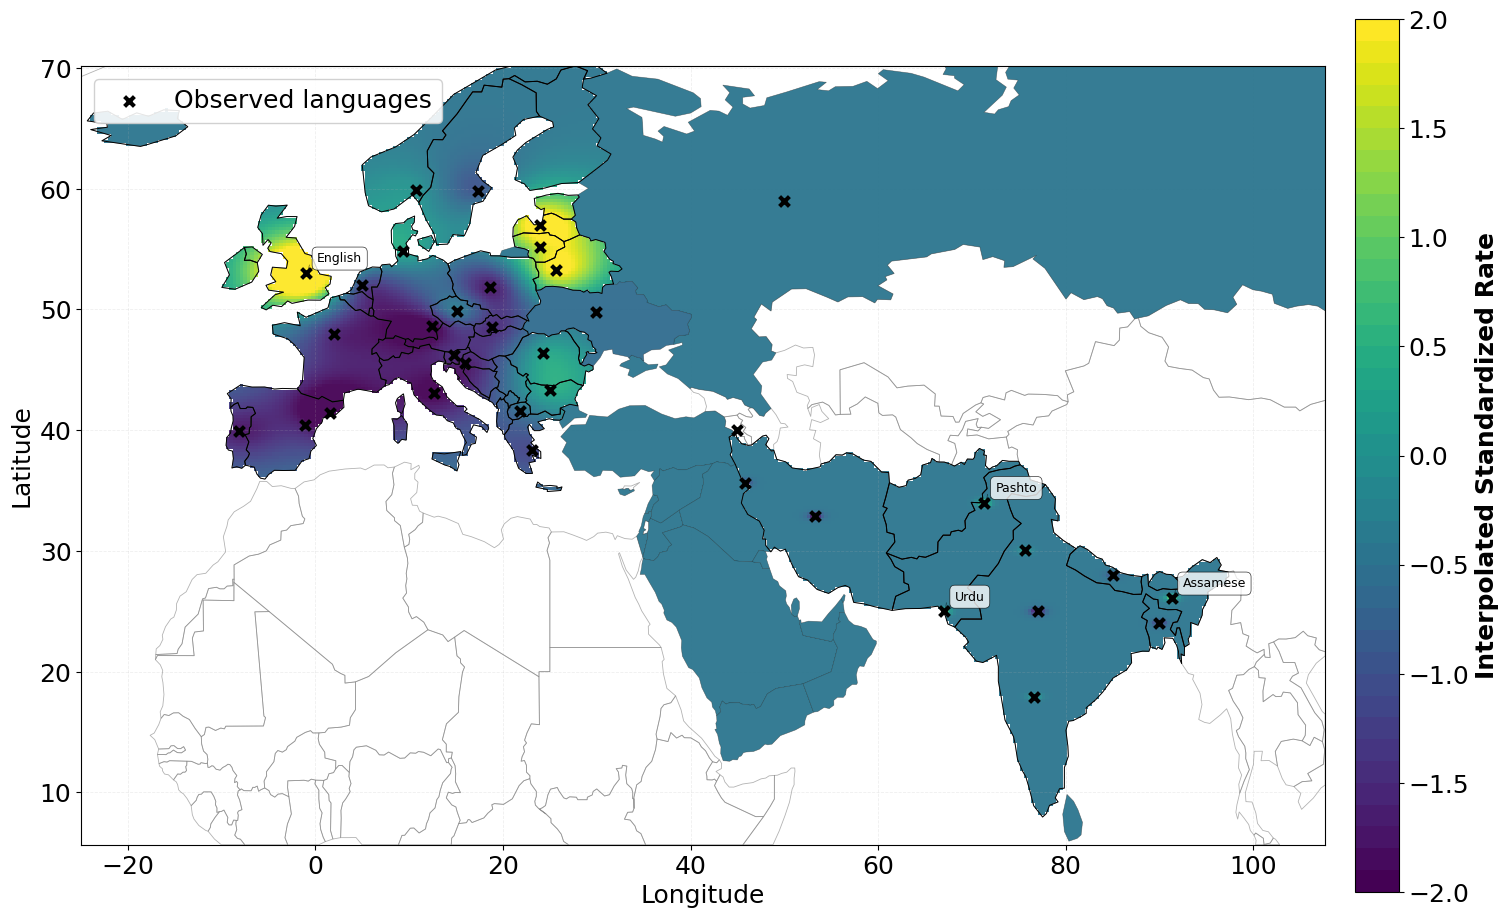

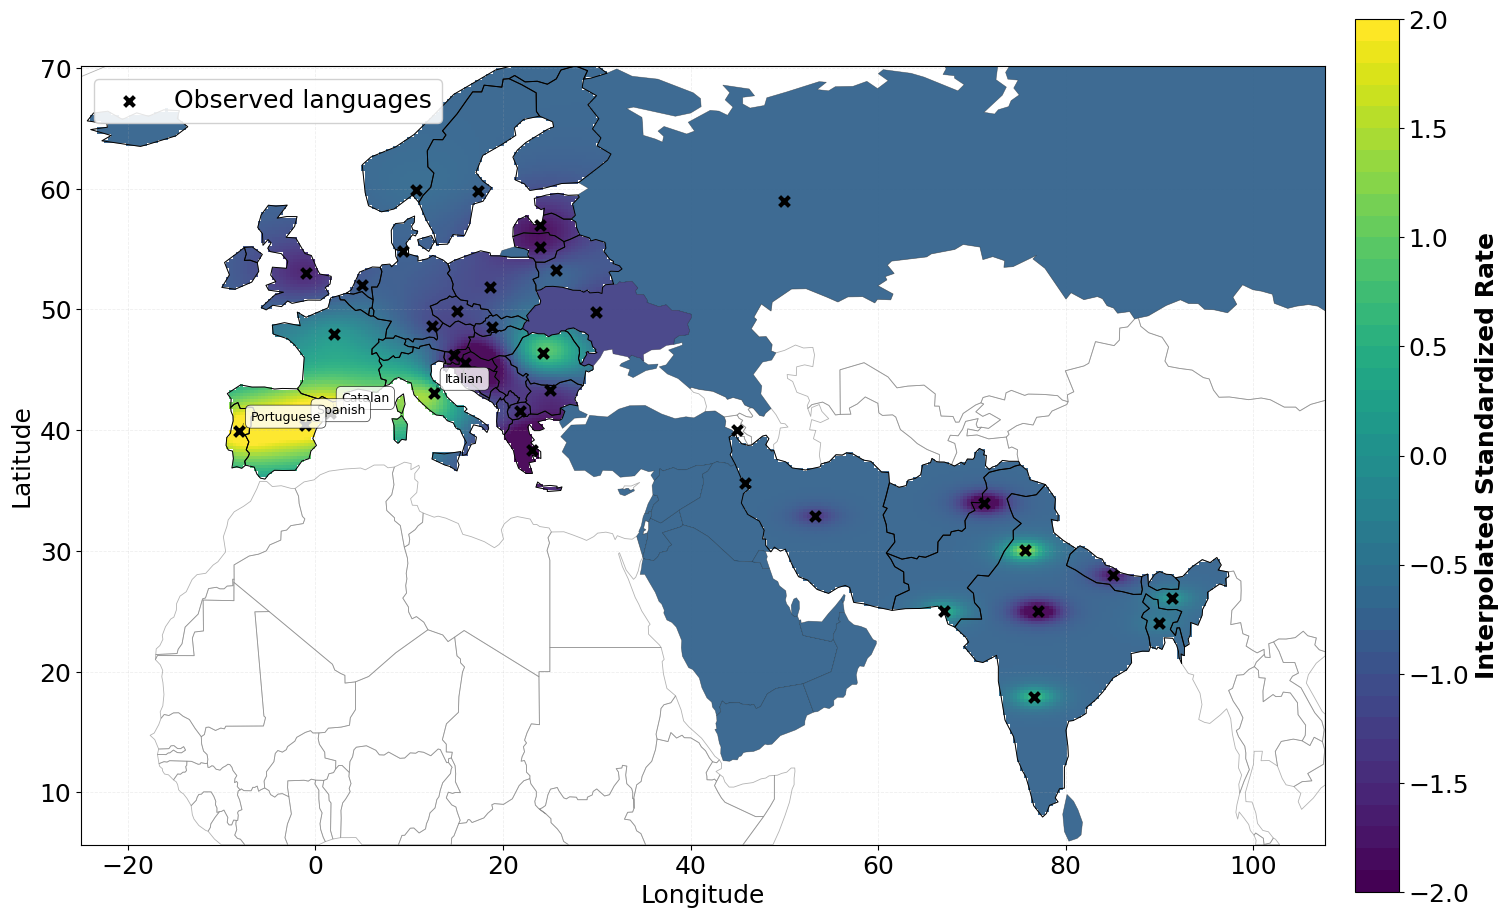

In [17]:
# gp_country_choropleth_eu_india_continuous.py
import os, sys
sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # CPU-only for TF/GPflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.prepared import prep
from sklearn.preprocessing import StandardScaler
import gpflow, tensorflow as tf
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

# ---------------- config ----------------
tree_names = ["heggarty2024", "long_v3_CCD0.0.25"]
tree_name_mapping = {
    "heggarty2024": "Cognates",
    "long_v3_CCD0.0.25": "Speech"
}
meta_dir   = "../speech_phylo/results_clean2"
out_dir    = "final_figures"
os.makedirs(out_dir, exist_ok=True)

# GP + plotting config
CMAP = "viridis"       # "Greens" also works nicely
GRID_N_LON = 350
GRID_N_LAT = 250
PAD_DEG = 15           # padding around ROI bbox (deg)
FIXED_NOISE = 1e-4      # small noise -> smooth interpolation

# OPTIONAL capitals CSV; flexible columns: name/country + lon/longitude + lat/latitude
capitals_csv = "../speech_phylo/aux/country_capitals.csv"

def _first_present(opts, cols):
    for c in opts:
        if c in cols:
            return c
    return None

capitals = None
if os.path.exists(capitals_csv):
    _cap = pd.read_csv(capitals_csv)
    name_col = _first_present(["name","country","Country","COUNTRY"], _cap.columns)
    lon_col  = _first_present(["lon","longitude","capital_lon","Lon","LONGITUDE"], _cap.columns)
    lat_col  = _first_present(["lat","latitude","capital_lat","Lat","LATITUDE"], _cap.columns)
    if name_col and lon_col and lat_col:
        capitals = _cap[[name_col, lon_col, lat_col]].rename(
            columns={name_col:"name", lon_col:"lon", lat_col:"lat"}
        )
        capitals["name"] = capitals["name"].astype(str).str.strip()

# ---------------- geography ----------------
world  = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
europe = world[world['continent'] == 'Europe'].copy()

mesa_list = [
    'Turkey','Cyprus','Syria','Lebanon','Israel','Jordan','Iraq','Iran',
    'Saudi Arabia','Yemen','Oman','United Arab Emirates','Qatar','Bahrain','Kuwait',
    'Afghanistan','Pakistan','India','Nepal','Bhutan','Bangladesh','Sri Lanka','Maldives'
]
mesa = world[world['name'].isin(mesa_list)].copy()

# ROI: Ireland → Bangladesh (tight + small pad)
ire = world.loc[world['name']=='Ireland'].total_bounds      # [minx, miny, maxx, maxy]
bgd = world.loc[world['name']=='Bangladesh'].total_bounds
ROI_MINX = min(ire[0], bgd[0]) - PAD_DEG
ROI_MAXX = max(ire[2], bgd[2]) + PAD_DEG
ROI_MINY = min(ire[1], bgd[1]) - PAD_DEG
ROI_MAXY = max(ire[3], bgd[3]) + PAD_DEG
ROI_BOX  = box(ROI_MINX, ROI_MINY, ROI_MAXX, ROI_MAXY)

# Convenience sets
europe_names = set(europe['name'])
mesa_names   = set(mesa['name'])

# ---------------- utilities ----------------
def tidy_meta(meta: pd.DataFrame) -> pd.DataFrame:
    meta = meta.rename(columns={"level_0": "language_true"})
    # split any "a,b" string columns into _lo/_hi numeric
    for col in list(meta.columns):
        if meta[col].dtype == object and meta[col].astype(str).str.contains(",", na=False).any():
            new_cols = meta[col].astype(str).str.split(",", expand=True)
            meta[f"{col}_lo"] = pd.to_numeric(new_cols[0], errors='coerce')
            meta[f"{col}_hi"] = pd.to_numeric(new_cols[1], errors='coerce')
            meta.drop(columns=[col], inplace=True)
    meta.drop(columns=meta.columns[1:7], errors='ignore', inplace=True)
    meta.rename(columns={"language_true": "language"}, inplace=True)
    meta["language"] = meta["language"].astype(str).str.strip()
    return meta.set_index("language")

def fit_gp_from_points(X, y):
    # Standardize X
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)
    # Standardize y (so kernels do not chase scale)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

    kernel = gpflow.kernels.Matern32(lengthscales=1.0, variance=1.0)
    model  = gpflow.models.GPR(data=(X_scaled, y_scaled.reshape(-1,1)), kernel=kernel, mean_function=None)

    model.likelihood.variance.assign(FIXED_NOISE)
    gpflow.set_trainable(model.likelihood.variance, False)

    gpflow.optimizers.Scipy().minimize(
        model.training_loss, variables=model.trainable_variables, options=dict(maxiter=500)
    )
    print("Optimized kernel:", model.kernel)
    print("Fixed noise variance:", model.likelihood.variance.numpy())
    return model, scaler_X, scaler_y

def get_country_point(row):
    """Use capital lon/lat if provided; else an inside-polygon representative point."""
    if capitals is not None:
        m = capitals.loc[capitals['name'] == row['name']]
        if len(m):
            return float(m.iloc[0]['lon']), float(m.iloc[0]['lat'])
    rp = row.geometry.representative_point()  # guaranteed inside polygon
    return float(rp.x), float(rp.y)

# ---------------- main ----------------
for tree_name in tree_names:
    # === Prepare Training Data (df) from metadata ===
    meta_path = f"{meta_dir}/metadata_{tree_name}.csv"
    if not os.path.exists(meta_path):
        print(f"[warn] {meta_path} not found; skipping.")
        continue

    meta = pd.read_csv(meta_path, sep=",")
    meta = tidy_meta(meta)

    # Build df to match example-like names
    df = pd.DataFrame({
        'sample_long_dd': meta['longitude'].to_numpy(),
        'sample_lat_dd' : meta['latitude'].to_numpy(),
        'sample_value'  : meta['rate_median'].to_numpy(),
    })

    # Geo points
    pts = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(lon, lat) for lon, lat in df[['sample_long_dd','sample_lat_dd']].to_numpy()],
        crs="EPSG:4326"
    )

    # Split training data by region (EU vs MESA)
    obs_eu = gpd.sjoin(pts, europe[['geometry','name']], how='inner', predicate='within')
    obs_me = gpd.sjoin(pts, mesa[['geometry','name']],   how='inner', predicate='within')

    if obs_eu.empty and obs_me.empty:
        print(f"[{tree_name}] No training points in Europe or MESA — nothing to plot.")
        continue

    # Fit two separate GPs (EU, MESA)
    model_eu = scaler_eu_X = scaler_eu_y = None
    model_me = scaler_me_X = scaler_me_y = None

    if not obs_eu.empty:
        Xe = obs_eu[['sample_long_dd','sample_lat_dd']].to_numpy()
        ye = obs_eu['sample_value'].to_numpy()
        model_eu, scaler_eu_X, scaler_eu_y = fit_gp_from_points(Xe, ye)

    if not obs_me.empty:
        Xm = obs_me[['sample_long_dd','sample_lat_dd']].to_numpy()
        ym = obs_me['sample_value'].to_numpy()
        model_me, scaler_me_X, scaler_me_y = fit_gp_from_points(Xm, ym)

    # --- Countries in ROI ---
    union_regions = pd.concat([europe, mesa], ignore_index=True)
    union_regions = union_regions.drop_duplicates(subset=['name']).reset_index(drop=True)
    countries_roi = gpd.clip(union_regions, ROI_BOX).copy()

    # Define continuous area: Europe minus Russia/Ukraine, plus India and neighboring countries
    eu_excl = europe[~europe['name'].isin(['Russia','Ukraine'])].copy()

    # Add India and neighboring MESA countries for continuous interpolation
    mesa_continuous = ['India', 'Afghanistan', 'Iran', 'Pakistan', 'Nepal', 'Bangladesh', 'Bhutan']
    mesa_cont_gdf = world[world['name'].isin(mesa_continuous)]

    cont_area = pd.concat([eu_excl, mesa_cont_gdf], ignore_index=True)
    cont_union = cont_area.unary_union
    cont_union_prep = prep(cont_union)

    # Build dense lon-lat grid over ROI
    lon_grid = np.linspace(ROI_MINX, ROI_MAXX, GRID_N_LON)
    lat_grid = np.linspace(ROI_MINY, ROI_MAXY, GRID_N_LAT)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)
    grid_points = np.column_stack([LON.ravel(), LAT.ravel()])

    # Build a mask for MESA continuous countries (India + neighbors)
    mesa_cont_union = mesa_cont_gdf.unary_union
    mesa_cont_prep = prep(mesa_cont_union)
    in_mesa_cont_mask = np.array([mesa_cont_prep.contains(Point(p[0], p[1])) for p in grid_points]).reshape(LON.shape)

    # Predict EU GP on whole grid (then mask to EU part)
    Z_eu = None
    if model_eu is not None:
        Xg_eu = scaler_eu_X.transform(grid_points)
        mean_eu, _ = model_eu.predict_f(Xg_eu)
        # Z_eu = scaler_eu_y.inverse_transform(mean_eu.numpy().reshape(-1,1)).ravel().reshape(LON.shape)
        Z_eu = mean_eu.numpy().reshape(-1,1).ravel().reshape(LON.shape)

    # Predict MESA GP on whole grid (then mask to India part)
    Z_me = None
    if model_me is not None:
        Xg_me = scaler_me_X.transform(grid_points)
        mean_me, _ = model_me.predict_f(Xg_me)
        # Z_me = scaler_me_y.inverse_transform(mean_me.numpy().reshape(-1,1)).ravel().reshape(LON.shape)
        Z_me = mean_me.numpy().reshape(-1,1).ravel().reshape(LON.shape)

    # # Build a mask specifically for India polygon inside ROI (to restrict MESA raster to India only)
    # india_union = india_gdf.unary_union
    # india_prep = prep(india_union)
    # in_india_mask = np.array([india_prep.contains(Point(p[0], p[1])) for p in grid_points]).reshape(LON.shape)
    in_cont_mask = np.array([cont_union_prep.contains(Point(p[0], p[1])) 
                            for p in grid_points]).reshape(LON.shape)

    # Final combined raster: EU GP inside EU_excl; MESA GP inside India; elsewhere NaN
    # Final combined raster: EU GP inside EU_excl; MESA GP inside MESA continuous countries; elsewhere NaN
    Z_raster = np.full(LON.shape, np.nan, dtype=float)
    if Z_eu is not None:
        # restrict to EU_excl only (continuous area minus MESA continuous countries)
        eu_only_mask = in_cont_mask & (~in_mesa_cont_mask)
        Z_raster[eu_only_mask] = Z_eu[eu_only_mask]
    if Z_me is not None:
        Z_raster[in_mesa_cont_mask] = Z_me[in_mesa_cont_mask]

    # --- Centroid-style predictions for the rest of the countries (within ROI but not in continuous area) ---
    # Compute prediction point per country (capital or representative point)
    coords = countries_roi.apply(get_country_point, axis=1, result_type='expand')
    coords.columns = ['lon','lat']
    countries_roi = pd.concat([countries_roi, coords], axis=1)

    # Split countries into continuous vs rest
    is_cont_country = countries_roi['name'].isin(set(eu_excl['name']).union(set(mesa_continuous)))
    countries_rest = countries_roi[~is_cont_country].copy()
    countries_cont = countries_roi[is_cont_country].copy()  # used only for boundaries

    # Predict centroid value for "rest" countries using their regional model
    pred_vals = []
    for _, row in countries_rest.iterrows():
        lon, lat = float(row['lon']), float(row['lat'])
        xy = np.array([[lon, lat]])
        if (row['name'] in europe_names) and (model_eu is not None):
            m, _ = model_eu.predict_f(scaler_eu_X.transform(xy))
            # val = scaler_eu_y.inverse_transform(m.numpy().reshape(-1,1)).ravel()[0]
            val = m.numpy().reshape(-1,1).ravel()[0]
        elif (row['name'] in mesa_names) and (model_me is not None):
            m, _ = model_me.predict_f(scaler_me_X.transform(xy))
            # val = scaler_me_y.inverse_transform(m.numpy().reshape(-1,1)).ravel()[0]
            val = m.numpy().reshape(-1,1).ravel()[0]
        else:
            val = np.nan
        pred_vals.append(val)
    countries_rest['pred_value'] = pred_vals

    # ------- Plot -------
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))

    # Base map
    world_roi = gpd.clip(world, ROI_BOX)
    world_roi.boundary.plot(ax=ax, linewidth=0.6, color='gray', alpha=0.6)
    world_roi.plot(ax=ax, color='white', alpha=0.0, edgecolor=None)

    # Shared color scaling across raster + centroid fills
    vals = []
    if np.isfinite(Z_raster).any():
        vals.append(Z_raster[np.isfinite(Z_raster)].ravel())
    if 'pred_value' in countries_rest.columns:
        vals.append(countries_rest['pred_value'].to_numpy())
    vals = np.concatenate([v[np.isfinite(v)] for v in vals]) if len(vals) else np.array([])
    if vals.size > 0:
        vmin, vmax = np.quantile(vals, 0.02), np.quantile(vals, 0.98)
    else:
        vmin = vmax = None

    # 1) Continuous raster (EU_excl + India)
    if np.isfinite(Z_raster).any():
        im = ax.pcolormesh(
            LON, LAT, Z_raster, shading="auto",
            cmap=CMAP, vmin=vmin, vmax=vmax, alpha=0.95, zorder=1
        )
    else:
        im = None

    # 2) Centroid-based country fills for the rest
    if not countries_rest.empty:
        countries_rest.plot(
            column='pred_value',
            ax=ax,
            cmap=CMAP,
            vmin=vmin, vmax=vmax,
            edgecolor='black', linewidth=0.1,
            alpha=0.95, zorder=2,
            missing_kwds=dict(color='lightgray', edgecolor='gray', alpha=0.3, hatch='//')
        )

    # Draw boundaries for continuous countries so the raster is nicely framed
    if not countries_cont.empty:
        countries_cont.boundary.plot(ax=ax, color='black', linewidth=0.7, zorder=3)

    # Observed points with scatter
    scatter = ax.scatter(
        meta["longitude"],
        meta["latitude"],
        s=50,
        c='black',
        alpha=1.0,
        linewidth=3.0,
        zorder=10,
        marker='x',  # lowercase 'x' for thin cross
        label='Observed languages'
    )

    # Optional: add legend
    ax.legend(loc='upper left', fontsize=18, framealpha=0.9)

    # Add labels for high-rate languages
    threshold = np.percentile(meta["rate_median"], 90)
    for lang, row in meta.iterrows():
        if row["rate_median"] > threshold:
            ax.annotate(
                lang,
                (row["longitude"], row["latitude"]),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                        edgecolor='black', alpha=0.8, linewidth=0.5),
                zorder=11,  # Higher than scatter points
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                            color='black', lw=0.5, alpha=0.6)
            )

    # Axes & labels
    ax.set_xlim(ROI_MINX, ROI_MAXX)
    ax.set_ylim(ROI_MINY, ROI_MAXY)

    tree_name = tree_name_mapping.get(tree_name, tree_name)
    # ax.set_title(f"{tree_name}",
                #  fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel("Longitude", fontsize=18)
    ax.set_ylabel("Latitude", fontsize=18)
    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=18)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.6)

    n_bins = 40  # Adjust this number for more/fewer bins
    bounds = np.linspace(-2, 2, n_bins + 1)
    norm = BoundaryNorm(bounds, ncolors=256)

    sm = ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.9, spacing='proportional')
    cbar.ax.tick_params(labelsize=18)

    cbar.set_label("Interpolated Standardized Rate", fontsize=18, fontweight="bold")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"country_map_eu_india_cont_{tree_name}_nbins{n_bins}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.savefig(f"final_figures/country_map_eu_india_cont_{tree_name}_nbins{n_bins}.pdf", dpi=300)
    print(f"[{tree_name}] wrote figure: {fig_path}")

## Figure 8

(36, 1)


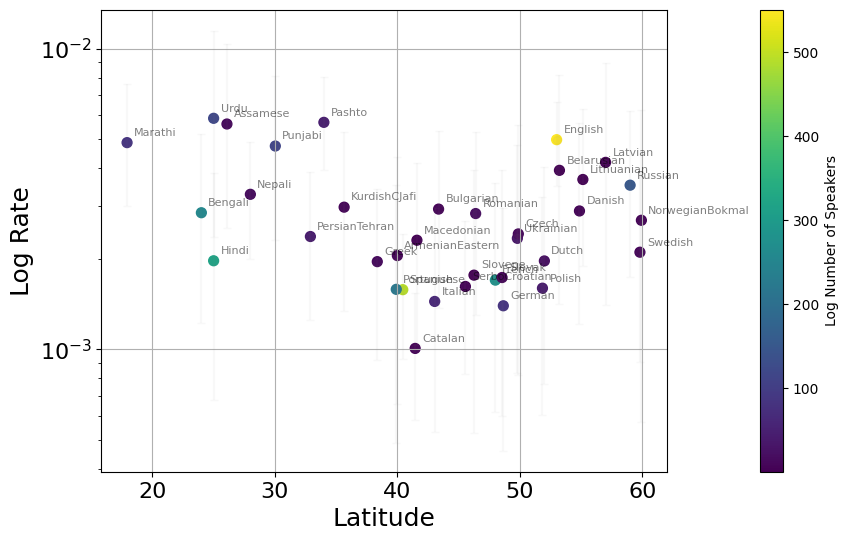

(36, 1)


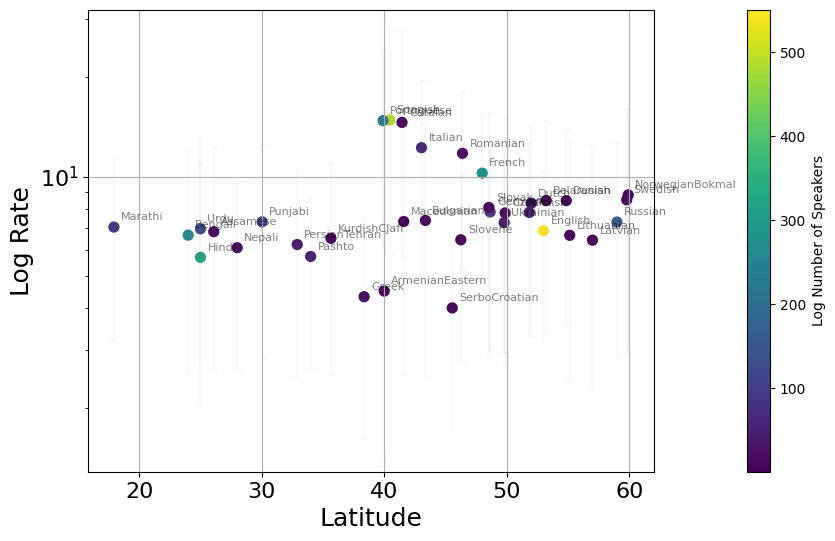

In [18]:
import numpy as np
# run_gpflow_shap.py
import os
import sys 
sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import argparse
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import pandas as pd
import numpy as np

for tree_name in ["heggarty2024", "long_v3_CCD0.0.25"]:

    # ─── 2) Load metadata, letting pandas read the header row ────
    meta = pd.read_csv(f"../speech_phylo/results_clean2/metadata_{tree_name}.csv", sep=",")
    meta = meta.rename(columns={"level_0": "language_true"})
    # for columns that have the format number1,number2, make it into separate columns with columnname_lo, columnname_hi
    # the dataframe is meta
    for col in meta.columns:
        if meta[col].dtype == object and meta[col].str.contains(",").any():
            # Split into two new columns
            new_cols = meta[col].str.split(",", expand=True)
            meta[f"{col}_lo"] = pd.to_numeric(new_cols[0], errors='coerce')
            meta[f"{col}_hi"] = pd.to_numeric(new_cols[1], errors='coerce')
            # Drop the original column
            meta = meta.drop(columns=[col])
    # remove columns 1-5
    # meta.drop(columns=meta.columns[1:7], errors='ignore')
    meta = meta.drop(columns=meta.columns[1:7], errors='ignore')
    meta = meta.rename(columns={"language_true": "language"})

    # If the column really is called "language", do:
    if "language" not in meta.columns:
        raise ValueError("Your metadata CSV does not have a column named 'language'")

    # Trim whitespace just in case
    meta["language"] = meta["language"].astype(str).str.strip()

    # Now set it as the index
    meta = meta.set_index("language")

    # ─── 4) Build X as before ───────────────────────────────
    longitudes   = meta["longitude"].to_numpy().reshape(-1, 1)
    latitudes    = meta["latitude"].to_numpy().reshape(-1, 1)
    log_speakers = np.log(meta["n_speakers"].to_numpy()).reshape(-1, 1)
    # hittite = meta["Hittite"].to_numpy().reshape(-1, 1)

    y = meta["rate_median"].to_numpy().reshape(-1, 1)
    print(y.shape)

    # plot rates vs longitude colored by n_speakers
    # plot rates vs longitude colored by n_speakers
    import matplotlib.pyplot as plt
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,6))
    sc = plt.scatter(meta["latitude"], y, c=meta["n_speakers"], cmap='viridis', s=50)
    # add 95% CI error bars. Column names are rate_95%_HPD_lo and rate_95%_HPD_hi
    # make this correct for log scale
    for lang, row in meta.iterrows():
        plt.errorbar(
            row["latitude"],
            row["rate_median"],
            yerr=[[row["rate_median"] - row["rate_95%_HPD_lo"]],
                  [row["rate_95%_HPD_hi"] - row["rate_median"]]],
            fmt='o',
            color='gray',
            alpha=0.05,
            capsize=3
        )
    # --- Label lone points with high n_speakers ---
    threshold = np.percentile(meta["n_speakers"], 95)  # top 5% as "high"
    for lang, row in meta.iterrows():
        plt.annotate(
            lang,
            (row["latitude"], row["rate_median"]),  # x,y coords
            textcoords="offset points",
            xytext=(5,5),
            fontsize=8,
            color="black",
            alpha=0.5
        )

    plt.yscale('log')
    plt.colorbar(sc, label='Log Number of Speakers', pad=0.12)
    # colorbar label fontsize
    plt.xlabel('Latitude', fontsize=18)
    plt.ylabel('Log Rate', fontsize=18)
    plt.tick_params(axis='x', labelsize=16)
    plt.tick_params(axis='y', labelsize=16)
    # plt.title(f'Log Rate vs latitudes colored by Number of Speakers for {tree_name}')
    plt.grid(True)

    plt.savefig(f"final_figures/rate_vs_latitude_{tree_name}.png", dpi=300)
    plt.savefig(f"final_figures/rate_vs_latitude_{tree_name}.pdf", dpi=300)
    plt.show()


(36, 1)


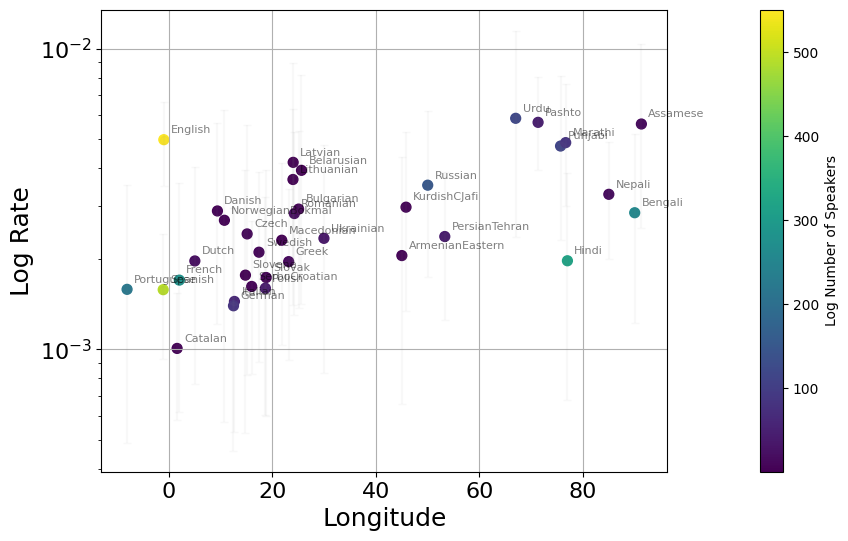

(36, 1)


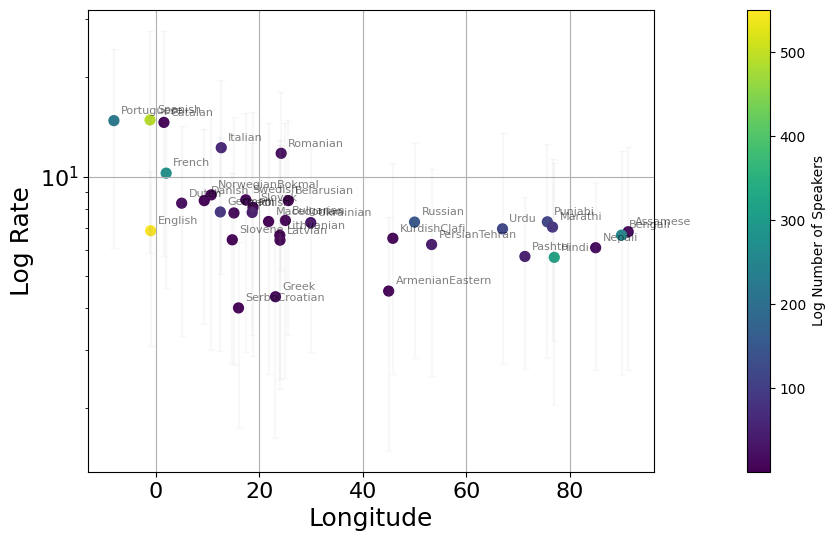

In [19]:
import numpy as np
# run_gpflow_shap.py
import os
import sys 
sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import argparse
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import pandas as pd
import numpy as np

for tree_name in ["heggarty2024", "long_v3_CCD0.0.25"]:

    # ─── 2) Load metadata, letting pandas read the header row ────
    meta = pd.read_csv(f"../speech_phylo/results_clean2/metadata_{tree_name}.csv", sep=",")
    meta = meta.rename(columns={"level_0": "language_true"})
    # for columns that have the format number1,number2, make it into separate columns with columnname_lo, columnname_hi
    # the dataframe is meta
    for col in meta.columns:
        if meta[col].dtype == object and meta[col].str.contains(",").any():
            # Split into two new columns
            new_cols = meta[col].str.split(",", expand=True)
            meta[f"{col}_lo"] = pd.to_numeric(new_cols[0], errors='coerce')
            meta[f"{col}_hi"] = pd.to_numeric(new_cols[1], errors='coerce')
            # Drop the original column
            meta = meta.drop(columns=[col])
    # remove columns 1-5
    # meta.drop(columns=meta.columns[1:7], errors='ignore')
    meta = meta.drop(columns=meta.columns[1:7], errors='ignore')
    meta = meta.rename(columns={"language_true": "language"})

    # If the column really is called "language", do:
    if "language" not in meta.columns:
        raise ValueError("Your metadata CSV does not have a column named 'language'")

    # Trim whitespace just in case
    meta["language"] = meta["language"].astype(str).str.strip()

    # Now set it as the index
    meta = meta.set_index("language")

    # ─── 4) Build X as before ───────────────────────────────
    longitudes   = meta["longitude"].to_numpy().reshape(-1, 1)
    latitudes    = meta["latitude"].to_numpy().reshape(-1, 1)
    log_speakers = np.log(meta["n_speakers"].to_numpy()).reshape(-1, 1)
    # hittite = meta["Hittite"].to_numpy().reshape(-1, 1)

    y = meta["rate_median"].to_numpy().reshape(-1, 1)
    print(y.shape)

    # plot rates vs longitude colored by n_speakers
    # plot rates vs longitude colored by n_speakers
    import matplotlib.pyplot as plt
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,6))
    sc = plt.scatter(meta["longitude"], y, c=meta["n_speakers"], cmap='viridis', s=50)
    # add 95% CI error bars. Column names are rate_95%_HPD_lo and rate_95%_HPD_hi
    # make this correct for log scale
    for lang, row in meta.iterrows():
        plt.errorbar(
            row["longitude"],
            row["rate_median"],
            yerr=[[row["rate_median"] - row["rate_95%_HPD_lo"]],
                  [row["rate_95%_HPD_hi"] - row["rate_median"]]],
            fmt='o',
            color='gray',
            alpha=0.05,
            capsize=3
        )
    # --- Label lone points with high n_speakers ---
    threshold = np.percentile(meta["n_speakers"], 95)  # top 5% as "high"
    for lang, row in meta.iterrows():
        plt.annotate(
            lang,
            (row["longitude"], row["rate_median"]),  # x,y coords
            textcoords="offset points",
            xytext=(5,5),
            fontsize=8,
            color="black",
            alpha=0.5
        )

    plt.yscale('log')
    plt.colorbar(sc, label='Log Number of Speakers', pad=0.12)
    # colorbar label fontsize
    plt.xlabel('Longitude', fontsize=18)
    plt.ylabel('Log Rate', fontsize=18)
    plt.tick_params(axis='x', labelsize=16)
    plt.tick_params(axis='y', labelsize=16)
    # plt.title(f'Log Rate vs longitudes colored by Number of Speakers for {tree_name}')
    plt.grid(True)

    plt.savefig(f"final_figures/rate_vs_longitude_{tree_name}.png", dpi=300)
    # save as pdf too
    plt.savefig(f"final_figures/rate_vs_longitude_{tree_name}.pdf", dpi=300)
    plt.show()


## Figure 4.5

In [ ]:
import dendropy

posterior_path = "/home/nclow23/src/phylaudio/dev/data/beast/eab44e7f-54cc-4469-87d1-282cc81e02c2/0.25/long_v3_44.trees"

trees_speech = dendropy.TreeList.get(
    path=posterior_path,
    schema="nexus",
    preserve_underscores=True
)

posterior_path = "/home/nclow23/src/phylaudio/dev/data/beast/heggarty2024/heggarty2024_fleurs_v4_889.trees"

trees_cognates = dendropy.TreeList.get(
    path=posterior_path,
    schema="nexus",
    preserve_underscores=True
)

In [ ]:
tree = trees_cognates[0]
tree

/home/hbz15/miniconda3/envs/oak_env/lib/python3.7/site-packages/ipykernel_launcher.py:94: RuntimeWarning: Mean of empty slice


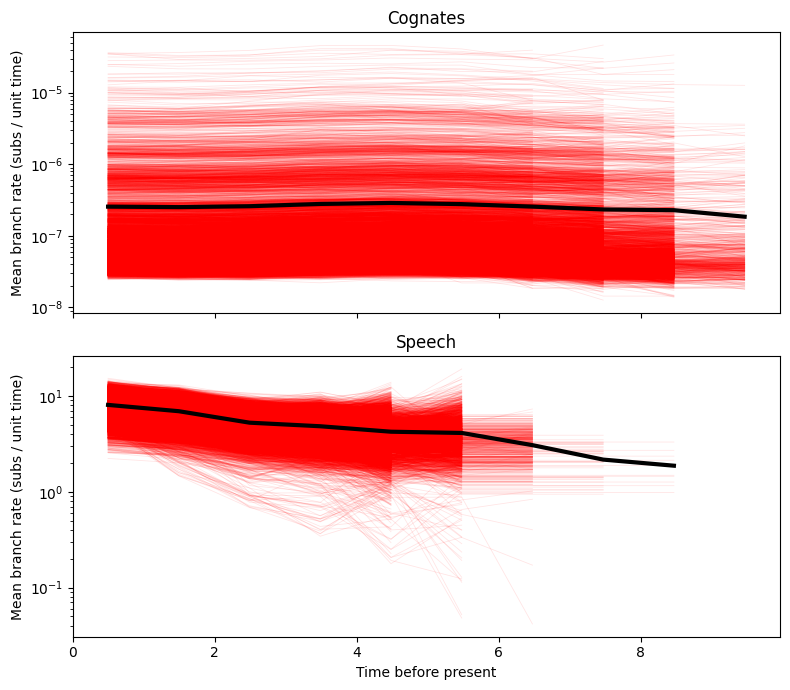

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dendropy as dp

# --- load ---
def load_trees_with_rates(path):
    return dp.TreeList.get_from_path(
        path, schema="nexus",
        preserve_underscores=True,
        extract_comment_metadata=True,  # REQUIRED to see [&rate=...]
    )

# --- extract per-branch segment: [child_age, parent_age] and rate ---
def _extract_segments(tree):
    """
    Returns arrays:
      T0: child age (younger, closer to present)
      T1: parent age (older, further in the past)
      R:  rate annotated on the edge leading to the child
    Only segments with positive duration are kept.
    """
    tree.calc_node_ages()
    T0, T1, R = [], [], []
    for nd in tree.preorder_node_iter():
        if nd.parent_node is None:
            continue  # root has no incoming edge
        tp, tc = float(nd.parent_node.age), float(nd.age)
        if tp <= tc:
            continue  # skip zero/negative-length edges if any
        # Try node then edge annotations for "rate"
        r = nd.annotations.get_value("rate")
        if r is None and hasattr(nd, "edge"):
            r = nd.edge.annotations.get_value("rate")
        r = float(r) if r is not None else np.nan
        T0.append(tc); T1.append(tp); R.append(r)
    T0 = np.asarray(T0); T1 = np.asarray(T1); R = np.asarray(R)
    good = np.isfinite(R) & (T1 > T0)
    return T0[good], T1[good], R[good]

# --- bin and average rates over time by INTERSECTION with each bin ---
def _rates_per_bin_intersection(trees, bins, min_per_bin=3, weight_by_overlap=False):
    """
    For each bin [bins[b], bins[b+1]], average the rates of all edges that
    intersect the bin. If weight_by_overlap=True, use the overlap length
    within the bin as weights; otherwise use a simple (uniform) average.
    """
    B = len(bins) - 1
    means = np.full((len(trees), B), np.nan)
    for i, tr in enumerate(trees):
        T0, T1, R = _extract_segments(tr)
        for b in range(B):
            lo, hi = bins[b], bins[b+1]
            # overlap length of each edge with the bin
            overlap = np.minimum(T1, hi) - np.maximum(T0, lo)
            msk = overlap > 0.0
            if msk.sum() >= min_per_bin:
                if weight_by_overlap:
                    w = overlap[msk]
                    means[i, b] = np.average(R[msk], weights=w if w.sum() > 0 else None)
                else:
                    means[i, b] = R[msk].mean()
    t_centers = 0.5 * (bins[:-1] + bins[1:])  # arithmetic centers (linear time)
    return t_centers, means

def _global_tmax(*groups):
    """Max root age across groups (after calc_node_ages)."""
    tmax = 0.0
    for group in groups:
        for tr in group:
            tr.calc_node_ages()
            # seed_node.age is the root age after calc_node_ages()
            tmax = max(tmax, float(tr.seed_node.age))
    return tmax

def plot_groups_same_xaxis(trees_A, trees_B, nbins=20, min_per_bin=3,
                           draw_median=True, weight_by_overlap=False):
    # Equal-width (linear) bins from present (0) to global max root age
    tmin = 0.0
    tmax = _global_tmax(trees_A, trees_B)
    bins = np.linspace(tmin, tmax, nbins + 1)

    # curves (intersection-based binning)
    tC, C = _rates_per_bin_intersection(trees_A, bins, min_per_bin, weight_by_overlap)
    tS, S = _rates_per_bin_intersection(trees_B, bins, min_per_bin, weight_by_overlap)

    # plot
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 7))
    for ax, mat, title in [(axes[0], C, "Cognates"), (axes[1], S, "Speech")]:
        for row in mat:
            valid = np.isfinite(row)
            if valid.any():
                ax.plot(tC[valid], row[valid], lw=0.6, alpha=0.1, color='red')
        if draw_median:
            median = np.nanmean(mat, axis=0)
            med_valid = np.isfinite(median)
            if med_valid.any():
                ax.plot(tC[med_valid], median[med_valid], lw=3, color="black", label="Mean rate")
        ax.set_ylabel("Mean branch rate (subs / unit time)")
        ax.set_title(title)

    # yscale log for both
    for ax in axes:
        ax.set_yscale("log")

    axes[-1].set_xlim(tmin, tmax)
    axes[-1].set_xlabel("Time before present")
    
    fig.tight_layout(); plt.show()
    plt.savefig(f"final_figures/rate_vs_longitude_{tree_name}.pdf", dpi=300)

    return tC, C, tS, S

# Example:
# trees_cognates = load_trees_with_rates("cognates.trees")
# trees_speech   = load_trees_with_rates("speech.trees")
# need to consider burn-in
tC, C, tS, S = plot_groups_same_xaxis(trees_cognates[20:], trees_speech[20:], nbins=10, min_per_bin=1)


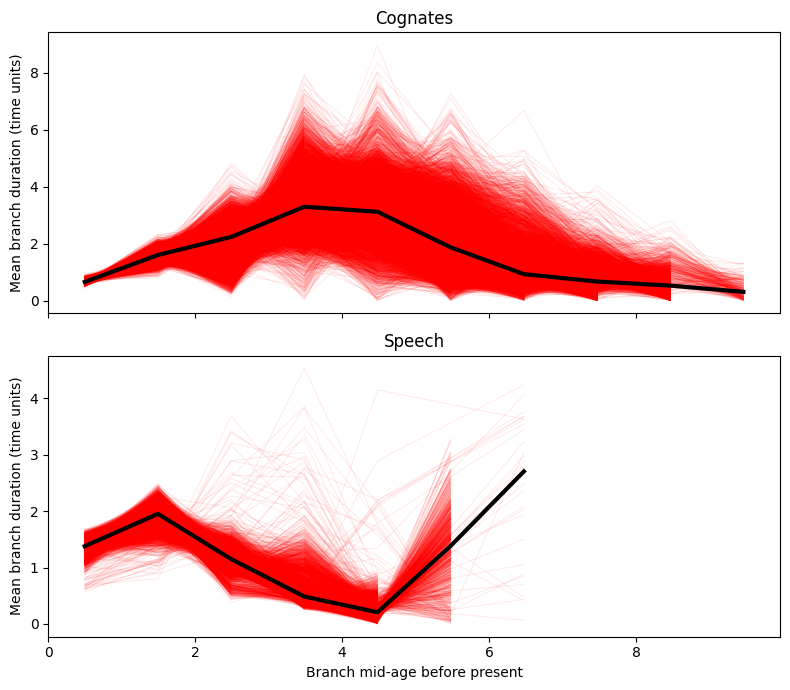

(array([0.49798321, 1.49394964, 2.48991606, 3.48588248, 4.48184891,
        5.47781533, 6.47378176, 7.46974818, 8.46571461, 9.46168103]),
 array([[0.67136878, 1.38372469, 2.71358857, ...,        nan,        nan,
                nan],
        [0.7258171 , 1.65748449, 2.65130024, ..., 1.40161212, 0.18255084,
                nan],
        [0.58277702, 1.91842811, 2.44378129, ...,        nan,        nan,
                nan],
        ...,
        [0.59518391, 1.7553311 , 2.51188514, ...,        nan,        nan,
                nan],
        [0.59735672, 1.65985968, 2.77857152, ...,        nan,        nan,
                nan],
        [0.74382835, 1.60873347, 2.19082288, ..., 0.46386315,        nan,
                nan]]),
 array([[0.62253185, 1.15495527, 2.89156849, ...,        nan,        nan,
                nan],
        [0.597296  , 1.04706201, 3.2103922 , ...,        nan,        nan,
                nan],
        [0.56634463, 1.04732457, 3.1740841 , ...,        nan,        nan,
     

In [ ]:
def _midage_segments(tree):
    tree.calc_node_ages()
    mids, durations = [], []
    for nd in tree.preorder_node_iter():
        if nd.parent_node is None:
            continue
        tp, tc = float(nd.parent_node.age), float(nd.age)
        dur = tp - tc
        if dur > 0:
            mids.append(0.5 * (tp + tc))
            durations.append(dur)
    return np.asarray(mids), np.asarray(durations)

def _midage_per_bin(trees, bins, min_per_bin=3):
    B = len(bins) - 1
    agg = np.full((len(trees), B), np.nan)
    for i, tr in enumerate(trees):
        mids, durs = _midage_segments(tr)
        idx = np.digitize(mids, bins, right=True) - 1
        for b in range(B):
            msk = idx == b
            if msk.sum() >= min_per_bin:
                agg[i, b] = np.nanmean(durs[msk])
    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, agg

def plot_midage_duration(trees_A, trees_B, nbins=20, min_per_bin=3, draw_median=True):
    tmin = 0.0
    tmax = _global_tmax(trees_A, trees_B)
    bins = np.linspace(tmin, tmax, nbins + 1)

    tC, C = _midage_per_bin(trees_A, bins, min_per_bin)
    _,  S = _midage_per_bin(trees_B, bins, min_per_bin)

    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 7))
    for ax, mat, title in [(axes[0], C, "Cognates"), (axes[1], S, "Speech")]:
        for row in mat:
            valid = np.isfinite(row)
            if valid.any():
                ax.plot(tC[valid], row[valid], lw=0.6, alpha=0.1, color='red')
        if draw_median:
            median = np.nanmedian(mat, axis=0)
            med_valid = np.isfinite(median)
            if med_valid.any():
                ax.plot(tC[med_valid], median[med_valid], lw=3, color="black", label="Median duration")
        ax.set_ylabel("Mean branch duration (time units)")
        ax.set_title(title)

    axes[-1].set_xlim(tmin, tmax)
    axes[-1].set_xlabel("Branch mid-age before present")
    fig.tight_layout()
    plt.show()
    plt.savefig(f"final_figures/midage_duration_{tree_name}.pdf", dpi=300)
    return tC, C, S

plot_midage_duration(trees_cognates[20:], trees_speech[20:], nbins=10, min_per_bin=1)

In [ ]:
# /home/nclow23/src/phylaudio/dev/data/beast/heggarty2024/heggarty2024_fleurs_v4_889.trees
# /home/nclow23/src/phylaudio/dev/data/beast/heggarty2024/heggarty2024_fleurs_v4_889.log.permeaning
# /home/nclow23/src/phylaudio/dev/data/beast/heggarty2024/heggarty2024_fleurs.xml.state

In [ ]:
# /home/nclow23/src/phylaudio/dev/drafts_0305.ipynb